<a href="https://colab.research.google.com/github/spesivan/colab-notes-v2/blob/main/RNN_and_LSTM_for_Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Umut Aksu
# 97 - https://www.youtube.com/watch?v=xmIx3sObk9E
# 98 - https://www.youtube.com/watch?v=iUtTx8ShdYE
# 99 - https://www.youtube.com/watch?v=gJfTDy3M3Gk

In [27]:
# !pip install tensorflow

In [4]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [5]:
from tensorflow.keras.datasets import mnist

In [6]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 [==============================] - 0s 0us/step


In [7]:
x_train.shape, x_test.shape

((60000, 28, 28), (10000, 28, 28))

In [8]:
y_train.shape, y_test.shape

((60000,), (10000,))

In [9]:
x_train.min(), x_train.max()

(0, 255)

In [10]:
y_train.min(), y_train.max()

(0, 9)

In [11]:
x_train = x_train/255.0
x_test = x_test/255.0

In [12]:
x_train.min(), x_train.max()

(0.0, 1.0)

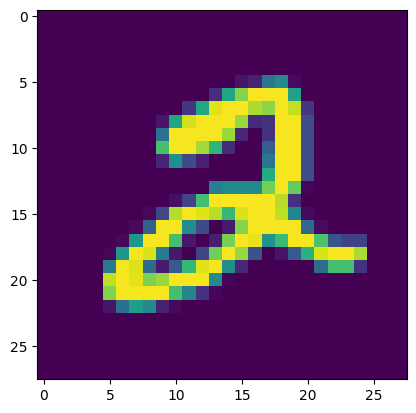

In [13]:
plt.imshow(x_train[5])

In [14]:
y_train[5]

2

In [15]:
# MODELLLL
model = tf.keras.models.Sequential()
# layer 1
model.add(tf.keras.layers.LSTM(units=128, activation='relu', return_sequences=True, input_shape=(28,28)))
model.add(tf.keras.layers.Dropout(0.2))
#layer 2
model.add(tf.keras.layers.LSTM(units=128, activation='relu'))
model.add(tf.keras.layers.Dropout(0.2))
# connection layer
model.add(tf.keras.layers.Dense(units=32, activation='relu'))
model.add(tf.keras.layers.Dropout(0.2))
#output layer
model.add(tf.keras.layers.Dense(units=10, activation='softmax'))

In [16]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 28, 128)           80384     
                                                                 
 dropout (Dropout)           (None, 28, 128)           0         
                                                                 
 lstm_1 (LSTM)               (None, 128)               131584    
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                                 
 dense (Dense)               (None, 32)                4128      
                                                                 
 dropout_2 (Dropout)         (None, 32)                0         
                                                                 
 dense_1 (Dense)             (None, 10)                3

In [17]:
opt = tf.keras.optimizers.Adam(learning_rate = 0.0001)

In [18]:
model.compile(optimizer= opt, loss= 'sparse_categorical_crossentropy', metrics=['accuracy'])

In [19]:
history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test,y_test))

Epoch 1/10
1875/1875 [==============================] - 100s 51ms/step - loss: 1.1290 - accuracy: 0.6136 - val_loss: 0.3716 - val_accuracy: 0.8913
Epoch 2/10
1875/1875 [==============================] - 89s 47ms/step - loss: 0.4000 - accuracy: 0.8773 - val_loss: 0.2863 - val_accuracy: 0.9117
Epoch 3/10
1875/1875 [==============================] - 84s 45ms/step - loss: 0.2731 - accuracy: 0.9210 - val_loss: 0.1478 - val_accuracy: 0.9540
Epoch 4/10
1875/1875 [==============================] - 84s 45ms/step - loss: 0.2099 - accuracy: 0.9401 - val_loss: 0.1212 - val_accuracy: 0.9632
Epoch 5/10
1875/1875 [==============================] - 89s 48ms/step - loss: 0.1728 - accuracy: 0.9511 - val_loss: 0.1135 - val_accuracy: 0.9646
Epoch 6/10
1875/1875 [==============================] - 87s 47ms/step - loss: 0.1454 - accuracy: 0.9597 - val_loss: 0.1093 - val_accuracy: 0.9671
Epoch 7/10
1875/1875 [==============================] - 87s 47ms/step - loss: 0.1285 - accuracy: 0.9638 - val_loss: 0.0804 

In [20]:
# y_pred = model.predict_classes(x_test)
y_pred = np.argmax(model.predict(x_test), axis=1)

313/313 [==============================] - 4s 13ms/step


In [21]:
i = 5
print(y_pred[i]), print(y_test[i])

1
1


(None, None)

In [22]:
 # confusion matrix
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[ 965    0    3    0    0    3    5    1    3    0]
 [   0 1132    2    0    0    0    1    0    0    0]
 [   1    1 1022    2    1    0    0    5    0    0]
 [   0    1    4  984    0    4    0    8    2    7]
 [   0    0    1    0  941    0    8    2    1   29]
 [   0    1    0    4    0  878    1    1    4    3]
 [   3    2    1    0    0    3  947    0    2    0]
 [   0    2   13    2    0    0    0  995    1   15]
 [   1    0    3    1    1    9    3    3  950    3]
 [   1    2    1    0    2    0    0    2    8  993]]


In [23]:
acc_cm = accuracy_score(y_test, y_pred)
print(acc_cm)

0.9807


In [24]:
def learning_curve(history, epoch):

    # training vs validation accuracy
    epoch_range = range(1, epoch+1)
    plt.plot(epoch_range, history.history['accuracy'])
    plt.plot(epoch_range, history.history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend(['Train', 'Val'], loc='upper left')
    plt.show()

    # training vs validation loss
    plt.plot(epoch_range, history.history['loss'])
    plt.plot(epoch_range, history.history['val_loss'])
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'val'], loc='upper left')
    plt.show()

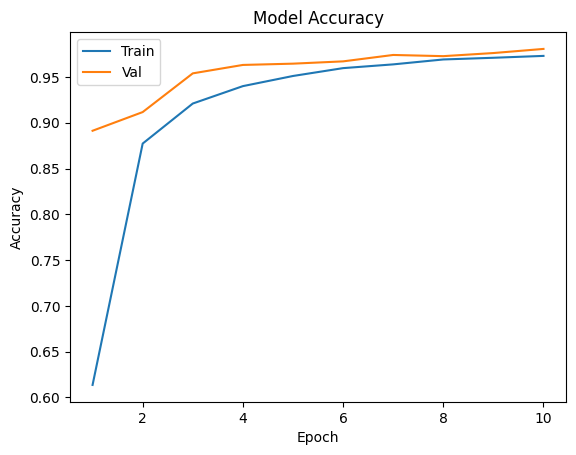

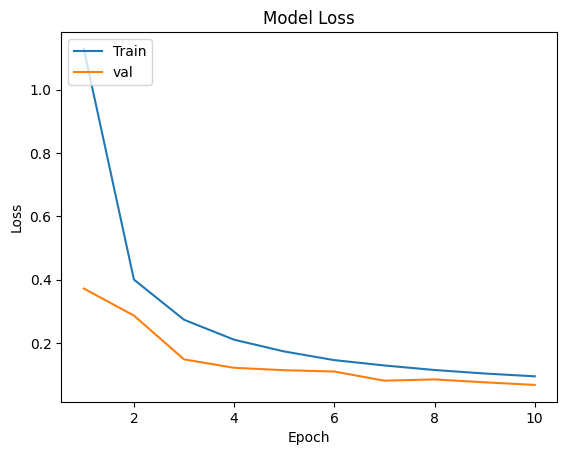

In [25]:
learning_curve(history,10)